In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Iterator, List, Optional, Tuple, Union
from bayesian_network import BayesNet
from utils import sample_forward, get_default_bayes_net, draw_graph

# Bayesian Network Parameter Learning

This notebook studies parameter learning for discrete Bayesian Networks when the dependency structure is known. It implements Maximum Likelihood Estimation and log-likelihood evaluation, then examines model complexity, generalization, and Laplace smoothing.

### BayesNet representation

The notebook uses the provided `BayesNet` representation to store conditional probability distribution tables and variable dependencies.

In [2]:
_A_, _B_, _C_ = 0, 1, 2
# create dummy PDTs
pdts = [
    (np.ones((2,))*0.5, (_A_,)), 
    (np.ones((2,2))*0.5, (_B_, _A_)), 
    (np.ones((2,2,2))*0.5, (_C_, _A_, _B_))
]

Each tuple in the list corresponds to a variable, where
 - the first element in each tuple contains the (conditional) PDT, 
 - the second one describes the table's semantics (indices).

A new BayesNet can be created by passing a tuple for each variable to the constructor. Use the asterisk (\*) operator to pass an arbitrary number of tuples as arguments to the constructor:

In [3]:
bn = BayesNet(*pdts)

In [4]:
if __name__ == '__main__':
    print(bn.pdts)
    print(bn.indices)

(array([0.5, 0.5]), array([[0.5, 0.5],
       [0.5, 0.5]]), array([[[0.5, 0.5],
        [0.5, 0.5]],

       [[0.5, 0.5],
        [0.5, 0.5]]]))
((0,), (1, 0), (2, 0, 1))


Note that they are returned as tuples to make sure they should not be modified. With `list(bn.pdts)` and `list(bn.indices)` you can convert them back to lists if needed.

We are also providing a new utility function to draw the structure of a BayesNet:

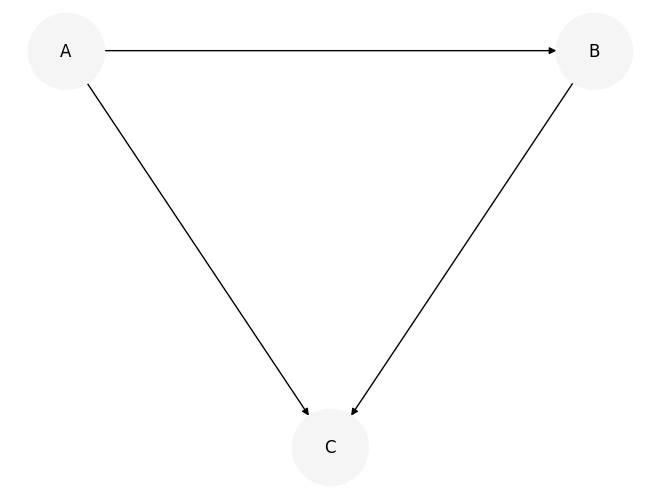

In [5]:
if __name__ == '__main__': # wrapped to prevent printing on import
    draw_graph(
        bn, 
        node_names=['A', 'B', 'C'], 
        pos={'A': [0., 1.], 'B': [1., 1.], 'C': [.5, .5]}
    )

In [6]:
if __name__ == '__main__': # wrapped to avoid printing on load
    help(draw_graph)

Help on function draw_graph in module utils:

draw_graph(
    bayes_net: bayesian_network.BayesNet,
    node_names: list = None,
    pos: dict = None
) -> None
    Draws the Bayesian net.
    :param bayes_net: a BayesNet object representing the graph structure to draw.
    :param node_names: Display Name of the variables.
                       Defaults to values for the stroke-example.
    :param pos: position of the variables (dict: key=variable_name, value: list: x, y).
                Defaults to values for the stroke-example.



---
# 1. Parameter Learning

In this first problem, we will assume that a fixed dependency graph structure between variables is given and learn the parameters (the complete Conditional Probability Distribution Table (CPDT)) from a set of events. Later, we will use log-likelihood to try to find a model structure that also generalizes to future data.
    
## Maximum Likelihood Estimation



`maximum_likelihood_estimate` takes  three parameters:
- `data` is a NumPy array of shape `(num_samples, num_variables)`.
- `variable_id` is the column index of the variable to estimate the distribution for.
- `parent_ids` is a tuple, containing the column indices of parent variables.
- `variable_cardinality` is the cardinality of the variables (aligned with columns of data)
- `alpha` is a non-negative integer, corresponding to pseudocounts in Laplace smoothing.

`maximum_likelihood_estimate` must return one object:
- A Maximum Likelihood Estimate (MLE) of the parameters in form of a `np.ndarray`. The first dimension (index `0`) of the returned array must correspond to variable `variable_id`, the remaining dimensions must be sorted according to `parent_ids`. Altogether, tuple `(variable_id, ) + parent_ids` gives the mapping of dimensions to variables.

Hint:
- To count elements in a Numpy array, you can simply loop over the data array.
- The smoothing parameter `alpha` is added to the counts of each possible event represented in the CPDT.

In [7]:
def maximum_likelihood_estimate(data: np.ndarray, variable_id: int, parent_ids: tuple=tuple(), variable_cardinality: Union[Tuple[int], None]=tuple(), alpha: int=0):
    """
    Estimates the conditional probability distribution of a (discrete) variable from data.
    :param data:    data to estimate distribution from
    :param variable_id:  column index corresponding to the variable we estimate the distribution for
    :param parent_ids: column indices of the variables the distribution is conditioned on
    :param variable_cardinality: cardinality of the variables (aligend with data); defaults to binary variables
    :param alpha: smoothing parameter, pseudocounts
    :returns: estimated conditional probability distribution table
    """
    
    assert type(parent_ids) == tuple
    assert type(variable_cardinality) == tuple
    
    if variable_cardinality is None or len(variable_cardinality) == 0: 
        variable_cardinality = (2,) * data.shape[1] # defaults to binary variables
    
    # mapping of axis to variable_id,
    # e.g. the variable with id variable_ids[i] is on axis i of the CPDT
    variable_ids = (variable_id,) + parent_ids

    
    shape = tuple(variable_cardinality[i] for i in variable_ids)
    cpdt = np.zeros(shape, dtype=float)
    
    for row in data:
        x_val = int(row[variable_id])
        parent_vals = tuple(int(row[p]) for p in parent_ids)
        
        cpdt[(x_val,) + parent_vals] += 1
    
    cpdt += alpha
    cpdt /= cpdt.sum(axis=0, keepdims=True)
    
    return cpdt

In [8]:
import traceback

any_failed = False

try:
    # sanity checks
    _A_, _B_, _C_, _D_, _E_ = 0, 1, 2, 3, 4
    # get the bayes net from the previous problem
    bayes_net = get_default_bayes_net()
    np.random.seed(0)
    # draw 100 samples
    data = sample_forward(bayes_net, 100)
    
    # get exact A form bayes net
    expected = bayes_net[_A_].pdt[:,0,0,0,0]
    # estimate A from the data
    actual = maximum_likelihood_estimate(data, _A_)
    # estimate should not be far off
    assert np.all(np.isclose(expected, actual, atol=0.05))
    
    # get exact B_A form bayes net
    expected = bayes_net[_B_].pdt[:,:,0,0,0].T
    # estimate B_A from data
    actual = maximum_likelihood_estimate(data, _B_, (_A_,))
    # estimate should not be far off
    assert np.all(np.isclose(expected, actual, atol=0.05))
    
    # test if alpha correctly added
    expected = [0.29166667, 0.70833333]
    # estimate A from the data with alpha=10
    actual = maximum_likelihood_estimate(data, _A_, alpha=10)
    # estimate should not be far off
    assert np.all(np.isclose(expected, actual, atol=0.05))
    
except Exception as e:
    print("Error:", e)
    traceback.print_exception(type(e), e, e.__traceback__)
    any_failed = True
finally:
    _ = None
assert not any_failed, "See error message above..."

### Log-Likelihood



`log_likelihood` takes two parameters:
- `data` is a NumPy array of shape `(num_samples, num_variables)`.
- `bayes_net` a BayesNet object representing the model $\mathcal{M}$ (containing already estimated CPDTs).

`log_likelihood` must return one object:
- The log-likelihood of the model given the data (i.e., a floating point number (<= 0)).

Hint:
- Recall that iterating over the variables in the BayesNet is super easy: `for variable in bayes_net: ...`.
- The probability distribution of variable $X$ given its parents $\mathit{pa}(X)$, $P(X \mid \mathit{pa}(X))$, can be obtained by passing the random event to the variable, i.e., `variable(data[i])`.
- Use the natural logarithm for your computations, i.e. `np.log`.

In [ ]:
def log_likelihood(data: np.ndarray, bayes_net: BayesNet):
    """
    Computes the log-likelihood of a given Bayesian network relative to the data.
    :param data: data to compute the log-likelihood relative to.
    :param bayes_net: Bayesian network model.
    :returns: the log-likelihood of the Bayesian network relative to the data.
    """    

    ll = 0
    
    
    num_samples = data.shape[0]

    pdts = bayes_net.pdts
    inds = bayes_net.indices

    for i in range(num_samples):
        event = data[i]

        for var_idx in range(len(pdts)):
            cpdt = pdts[var_idx]
            var_id = inds[var_idx][0]
            parent_ids = inds[var_idx][1:]

            x = int(event[var_id])

            # case: no parents → 1D cpdt
            if len(parent_ids) == 0:
            # cpdt might be 1D or have extra singleton dims; always reduce to 1D
                arr = np.squeeze(cpdt)
                p = arr[x]

            else:
                # build index (x, parent1, parent2, ...)
                parent_vals = tuple(int(event[p]) for p in parent_ids)
                idx = (x,) + parent_vals
                # cpdt may have singleton dims; squeeze before indexing
                arr = np.squeeze(cpdt)
                p = arr[idx]

            ll += np.log(p)
    return ll

In [28]:
any_failed = False
try:
    # sanity checks
    # get the bayes net from the previous problem
    bayes_net = get_default_bayes_net()
    np.random.seed(0)
    # draw 100 samples
    data = sample_forward(bayes_net, 100)
    
    # expected log-likelihood
    expected = -215.9
    # actual log-likelihood
    actual = log_likelihood(data, bayes_net)
    # must be close
    assert np.all(np.isclose(expected, actual, atol=10.0))
    
except Exception as e:
    print("Error:", e)
    traceback.print_exception(type(e), e, e.__traceback__)
    any_failed = True
finally:
    _ = None
# remove unused variables
del data
del bayes_net

assert not any_failed, "See error message above..."

## Model Complexity and Generalization   

After watching hours of medical dramas on television, you try to figure out the perfect prediction model for strokes. Some of your AI colleagues told you about how Bayesian networks can be used for symptom diagnosis, so you decide to model your ideas using this technique. 

Let's assume that you magically know the true underlying Bayes model (structure and parameters); all variables in this example are boolean (false=0 or true=1).  



The conditional probability tables are given as follows:

In order to find a good model, you would need to collect a lot of training examples. But since we know the true undelying model, you can instead just sample 5000 events from this network as the training data, and 5000 samples as the test data.

In [30]:
_A_, _H_, _S_, _C_, _V_ = 0, 1, 2, 3, 4
A = np.array([0.01, 0.99])
H_A = np.array([[0.9, 0.8], [0.1, 0.2]])
S_H = np.array([[0.9, 0.85], [0.1, 0.15]])
C_AS = np.array([[[0.8, 0.7], [0.85, 0.45]], [[0.2, 0.3], [0.15, 0.55]]])
V_S = np.array([[0.1, 0.2], [0.9, 0.8]])

# this bayes net represents the true underlying full joint distribution in the medical world 
true_bayes_net = BayesNet(
    (A, (_A_,)),
    (H_A, (_H_,_A_)),
    (S_H, (_S_,_H_)),
    (C_AS, (_C_,_A_,_S_)),
    (V_S, (_V_,_S_))
)
np.random.seed(0)
train = sample_forward(true_bayes_net, 5000)
test = sample_forward(true_bayes_net, 5000)

### Experiment 1: Learning the True Structure


  
  
Store the CPDTs into the provided variables. The dimensions of the CPDT must be sorted according to the naming of the variable, e.g., in C_AS, dimension 0 corresponds to C, dimension 1 to A, and dimension 2 to S.

In [ ]:
_A_, _H_, _S_, _C_, _V_ = 0, 1, 2, 3, 4

A, H_A, S_H, C_AS, V_S = None, None, None, None, None


# estimate CPDTs from train
# assume all variables are binary
variable_cardinality = (2,) * train.shape[1]

A = maximum_likelihood_estimate(train, _A_, parent_ids=(), 
                                variable_cardinality=variable_cardinality, alpha=1)

H_A = maximum_likelihood_estimate(train, _H_, parent_ids=(_A_,), 
                                  variable_cardinality=variable_cardinality, alpha=1)

S_H = maximum_likelihood_estimate(train, _S_, parent_ids=(_H_,), 
                                  variable_cardinality=variable_cardinality, alpha=1)

C_AS = maximum_likelihood_estimate(train, _C_, parent_ids=(_A_, _S_), 
                                   variable_cardinality=variable_cardinality, alpha=1)

V_S = maximum_likelihood_estimate(train, _V_, parent_ids=(_S_,), 
                                  variable_cardinality=variable_cardinality, alpha=1)


# begin sanity check
assert np.all(np.isclose(A.sum(axis=0), 1))
assert np.all(np.isclose(H_A.sum(axis=0), 1))
assert np.all(np.isclose(S_H.sum(axis=0), 1))
assert np.all(np.isclose(C_AS.sum(axis=0), 1))
assert np.all(np.isclose(V_S.sum(axis=0), 1))
# end sanity check

bayes_net_1 = BayesNet(
    (A, (_A_,)),
    (H_A, (_H_,_A_)),
    (S_H, (_S_,_H_)),
    (C_AS, (_C_,_A_,_S_)),
    (V_S, (_V_,_S_))
)

tr_log_likelihood_1 = 0


bayes_net_1 = BayesNet(
    (A, (_A_,)),
    (H_A, (_H_, _A_)),
    (S_H, (_S_, _H_)),
    (C_AS, (_C_, _A_, _S_)),
    (V_S, (_V_, _S_))
)

tr_log_likelihood_1 = log_likelihood(train, bayes_net_1)

In [32]:
# sanity check
assert tr_log_likelihood_1 < -8000
assert tr_log_likelihood_1 > -9000


Back to our strokes model: Having no idea of the true underlying network structure, you decide to try out the following very simple model first:
    






Store the CPDTs into the provided variables.

In [33]:
_A_, _H_, _S_, _C_, _V_ = 0, 1, 2, 3, 4

A, H, S, C, V = None, None, None, None, None


# assume all variables are binary
variable_cardinality = (2,) * train.shape[1]

A = maximum_likelihood_estimate(train, _A_, parent_ids=(), 
                                variable_cardinality=variable_cardinality, alpha=1)

H = maximum_likelihood_estimate(train, _H_, parent_ids=(), 
                                variable_cardinality=variable_cardinality, alpha=1)

S = maximum_likelihood_estimate(train, _S_, parent_ids=(), 
                                variable_cardinality=variable_cardinality, alpha=1)

C = maximum_likelihood_estimate(train, _C_, parent_ids=(), 
                                variable_cardinality=variable_cardinality, alpha=1)

V = maximum_likelihood_estimate(train, _V_, parent_ids=(), 
                                variable_cardinality=variable_cardinality, alpha=1)

# begin sanity check
assert np.all(np.isclose(A.sum(axis=0), 1))
assert np.all(np.isclose(H.sum(axis=0), 1))
assert np.all(np.isclose(S.sum(axis=0), 1))
assert np.all(np.isclose(C.sum(axis=0), 1))
assert np.all(np.isclose(V.sum(axis=0), 1))
# end sanity check

bayes_net_2 = BayesNet(
    (A, (_A_,)),
    (H, (_H_,)),
    (S, (_S_,)),
    (C, (_C_,)),
    (V, (_V_,))
)

tr_log_likelihood_2 = 0


tr_log_likelihood_2 = log_likelihood(train, bayes_net_2)

In [34]:
# sanity check
assert tr_log_likelihood_2 < -8000
assert tr_log_likelihood_2 > -9000


Unhappy with the result, you decide to try out a second, more complex model:





Store the CPDTs into the provided variables. The dimensions of the CPDT must be sorted according to the naming of the variable, e.g., in C_AS, dimension 0 corresponds to C, dimension 1 to A, and dimension 2 to S.

In [ ]:
_A_, _H_, _S_, _C_, _V_ = 0, 1, 2, 3, 4

A, H_A, S_AH, C_AS, V_CS = None, None, None, None, None


# assume all variables are binary
variable_cardinality = (2,) * train.shape[1]

A = maximum_likelihood_estimate(train, _A_, parent_ids=(), 
                                variable_cardinality=variable_cardinality, alpha=1)

H_A = maximum_likelihood_estimate(train, _H_, parent_ids=(_A_,), 
                                  variable_cardinality=variable_cardinality, alpha=1)

S_AH = maximum_likelihood_estimate(train, _S_, parent_ids=(_A_, _H_), 
                                   variable_cardinality=variable_cardinality, alpha=1)

C_AS = maximum_likelihood_estimate(train, _C_, parent_ids=(_A_, _S_), 
                                   variable_cardinality=variable_cardinality, alpha=1)

V_CS = maximum_likelihood_estimate(train, _V_, parent_ids=(_C_, _S_), 
                                   variable_cardinality=variable_cardinality, alpha=1)

# begin sanity check
assert np.all(np.isclose(A.sum(axis=0), 1))
assert np.all(np.isclose(H_A.sum(axis=0), 1))
assert np.all(np.isclose(S_AH.sum(axis=0), 1))
assert np.all(np.isclose(C_AS.sum(axis=0), 1))
assert np.all(np.isclose(V_CS.sum(axis=0), 1))
# end sanity check

bayes_net_3 = BayesNet(
    (A, (_A_,)),
    (H_A, (_H_,_A_)),
    (S_AH, (_S_,_A_,_H_)),
    (C_AS, (_C_,_A_,_S_)),
    (V_CS, (_V_,_C_,_S_))
)

tr_log_likelihood_3 = 0


tr_log_likelihood_3 = log_likelihood(train, bayes_net_3)

In [ ]:
# sanity check
assert tr_log_likelihood_3 < -8000
assert tr_log_likelihood_3 > -9000


### Train Log-Likelihood Comparison

Compare the log-likelihoods w.r.t the training data of Model **M1** (having the true underlying structure) to the two new models (**M2** - no edges, **M3** - complex model).

In [37]:
if __name__ == '__main__': # wrapped to prevent printing on import
    print('logP(train|M1) = {}'.format(tr_log_likelihood_1))
    print('logP(train|M2) = {}'.format(tr_log_likelihood_2))
    print('logP(train|M3) = {}'.format(tr_log_likelihood_3))

logP(train|M1) = -8508.685232041225
logP(train|M2) = -8740.046009657486
logP(train|M3) = -8504.586759702866


### Observation: Training Fit vs. Model Complexity

A more complex Bayesian Network can achieve a higher training log-likelihood because additional parameters provide greater flexibility. This does not necessarily imply better generalization.

### Test Log-Likelihood Comparison

Finally, we compute the test log-likelihood of the model **M1** (having the true underlying structure) and the newly created models **M2** and **M3**.

In [38]:
if __name__ == '__main__': # wrapped to prevent printing on import
    te_log_likelihood_1 = log_likelihood(test, bayes_net_1)
    te_log_likelihood_2 = log_likelihood(test, bayes_net_2)
    te_log_likelihood_3 = log_likelihood(test, bayes_net_3)

    print('logP(test|M1) = {}'.format(te_log_likelihood_1))
    print('logP(test|M2) = {}'.format(te_log_likelihood_2))
    print('logP(test|M3) = {}'.format(te_log_likelihood_3))

logP(test|M1) = -8376.75201088704
logP(test|M2) = -8598.605706002614
logP(test|M3) = -8380.044535280806


### Observation: Generalization

On unseen test data, the model with the correct underlying structure can generalize better than an unnecessarily complex model. This illustrates the effect of overfitting.

On the test data, M1 now performs best while M3 performs slightly worse, because the extra parameters of M3 cause overfitting to the training set and reduce its generalization ability; M2 still performs worst because it ignores all dependencies.

### Why Laplace Smoothing Matters

With small datasets, some parent–child configurations may never occur. Maximum likelihood can then produce zero probabilities. Laplace smoothing adds pseudocounts (for example, `alpha=1`) to avoid zero-probability configurations and improve numerical robustness.

In [39]:
if __name__ == '__main__': # wrapped to prevent execution on import
    np.random.seed(0)
    # we generate a new training set consisting of 100 samples
    train = sample_forward(true_bayes_net, 100)  

    A = maximum_likelihood_estimate(train, _A_)
    H_A = maximum_likelihood_estimate(train, _H_, (_A_,))
    S_AH = maximum_likelihood_estimate(train, _S_, (_A_, _H_,))
    C_AS = maximum_likelihood_estimate(train, _C_, (_A_, _S_))
    V_CS = maximum_likelihood_estimate(train, _V_, (_S_,_C_,))

    bayes_net_3 = BayesNet(
        (A, (_A_,)),
        (H_A, (_H_,_A_)),
        (S_AH, (_S_,_A_,_H_)),
        (C_AS, (_C_,_A_,_S_)),
        (V_CS, (_V_,_C_,_S_))
    )

/var/folders/4h/_9kc0dqn0jl725g1mxdrbnfw0000gn/T/ipykernel_43147/231320914.py:33: RuntimeWarning: invalid value encountered in divide
  cpdt /= cpdt.sum(axis=0, keepdims=True)


AssertionError: Probabilities on axis 0 have to sum to 1!